# 08 — Event Study: Do Reported Incidents Cause Measurable Delays?

**ENAI 603 · WMATA Delay Project · Lens C (Causal)**

Main question: *when WMATA reports a "Delay" incident, do we observe a measurable rise in the delay rate of the affected line in the surrounding time window?*

Design:

1. Identify each unique "Delay" incident in the `incidents` table.
2. Define **t = 0** as the first moment the incident appeared in the API feed.
3. For each affected line, compute the delay rate in 5-minute buckets across a window of **−60 to +120 min** around t = 0.
4. Average the curve across all incidents aligned at t = 0.

If incidents are truly causal, we expect a step change at t ≈ 0 followed by a gradual decay back toward the baseline.

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.figsize"] = (12, 5)

PROJ = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(PROJ, "data")
FIG_DIR = os.path.join(PROJ, "reports", "figures")
DB_PATH = os.path.join(DATA_DIR, "wmata.db")
CSV_PATH = os.path.join(DATA_DIR, "features.csv")
INCIDENTS_CSV = os.path.join(DATA_DIR, "incidents.csv")
os.makedirs(FIG_DIR, exist_ok=True)

LINE_COLORS = {"RD": "#C80F22", "BL": "#009CDE", "GR": "#00B140",
               "YL": "#FFD100", "OR": "#F7941D", "SV": "#A2A4A1"}
LINE_NAMES  = {"RD": "Red", "BL": "Blue", "GR": "Green",
               "YL": "Yellow", "OR": "Orange", "SV": "Silver"}


## 1. Load the data

We use `features.csv` (orphans excluded) for predictions, and the raw `incidents` table from SQLite to access `incident_id` and `incident_type`. Falls back to `data/incidents.csv` if the DB isn't available.

In [2]:
df = pd.read_csv(CSV_PATH, parse_dates=["collected_at"], usecols=[
    "collected_at", "line", "is_delayed", "is_orphan",
])
df["collected_at"] = pd.to_datetime(df["collected_at"], utc=True)
df = df[df["is_orphan"] == 0].copy()
df = df[df["line"].isin(LINE_COLORS.keys())].copy()
print(f"Predictions (orphans filtered): {len(df):,} rows")
print(f"Date range: {df['collected_at'].min()} -> {df['collected_at'].max()}")

Predictions (orphans filtered): 9,215,922 rows
Date range: 2026-03-11 02:00:05.155939+00:00 -> 2026-04-28 22:24:04.713007+00:00


In [3]:
# Prefer SQLite; fall back to incidents.csv if the DB is missing
if os.path.exists(DB_PATH):
    conn = sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True)
    incidents_raw = pd.read_sql(
        "SELECT collected_at, incident_id, incident_type, description, lines_affected FROM incidents",
        conn,
    )
    conn.close()
    print("Loaded incidents from SQLite.")
else:
    incidents_raw = pd.read_csv(INCIDENTS_CSV)
    print("Loaded incidents from incidents.csv.")
incidents_raw["collected_at"] = pd.to_datetime(incidents_raw["collected_at"], utc=True)
print(f"Raw incident rows: {len(incidents_raw):,} (each incident is repeated every 5-min poll while active)")

Loaded incidents from SQLite.
Raw incident rows: 21,384 (each incident is repeated every 5-min poll while active)


## 2. Collapse incidents into one event per `incident_id`

The same incident reappears in every polling cycle while it is active. For an event study, we want one event per incident with its real activity window.

In [4]:
events = (
    incidents_raw
    .groupby("incident_id")
    .agg(
        first_seen=("collected_at", "min"),
        last_seen=("collected_at", "max"),
        incident_type=("incident_type", "first"),
        description=("description", "first"),
        lines_affected=("lines_affected", "first"),
    )
    .reset_index()
)
events["duration_min"] = (events["last_seen"] - events["first_seen"]).dt.total_seconds() / 60
print(f"Unique incidents: {len(events):,}")
print(f"\nBy type:")
print(events["incident_type"].value_counts().to_string())
print(f"\nMedian incident duration: {events['duration_min'].median():.0f} min")

Unique incidents: 186



By type:
incident_type
Delay    144
Alert     42

Median incident duration: 62 min


## 3. Filter to type `Delay` and expand by affected line

`lines_affected` is stored as `"RD;BL"`. Each incident can affect multiple lines; an event study unit must be one *(incident, line)* pair.

In [5]:
delay_events = events[events["incident_type"] == "Delay"].copy()
print(f"Delay incidents: {len(delay_events):,}")

VALID_LINES = set(LINE_COLORS.keys())
expanded_rows = []
for _, row in delay_events.iterrows():
    if pd.isna(row["lines_affected"]):
        continue
    for code_ in str(row["lines_affected"]).split(";"):
        code_ = code_.strip().upper()
        if code_ in VALID_LINES:
            expanded_rows.append({
                "incident_id": row["incident_id"],
                "line": code_,
                "t0": row["first_seen"],
                "duration_min": row["duration_min"],
                "description": row["description"],
            })

delay_events_x = pd.DataFrame(expanded_rows)
print(f"(incident x affected line) pairs: {len(delay_events_x):,}")

Delay incidents: 144
(incident x affected line) pairs: 203


## 4. Build the event-study curve

For each *(incident, line)* pair, take the predictions of that line in a window around t and group them into 5-min buckets relative to t = 0. Then average the delay rate per bucket across all events.

In [6]:
WINDOW_BEFORE_MIN = 60
WINDOW_AFTER_MIN = 120
BUCKET_SIZE_MIN = 5

# Index predictions by line, sorted by collected_at, for fast slicing
df_by_line = {ln: g.sort_values("collected_at").reset_index(drop=True)
              for ln, g in df.groupby("line")}

bucket_rows = []
for _, ev in delay_events_x.iterrows():
    line = ev["line"]
    t0 = ev["t0"]
    if line not in df_by_line:
        continue

    sub = df_by_line[line]
    mask = (
        (sub["collected_at"] >= t0 - pd.Timedelta(minutes=WINDOW_BEFORE_MIN)) &
        (sub["collected_at"] <= t0 + pd.Timedelta(minutes=WINDOW_AFTER_MIN))
    )
    win = sub.loc[mask, ["collected_at", "is_delayed"]]
    if len(win) == 0:
        continue

    rel_min = (win["collected_at"] - t0).dt.total_seconds() / 60
    bucket = (rel_min // BUCKET_SIZE_MIN) * BUCKET_SIZE_MIN
    grp = win.groupby(bucket)["is_delayed"].agg(["mean", "count"]).reset_index()
    grp = grp.rename(columns={"collected_at": "bucket_min"})
    grp["incident_id"] = ev["incident_id"]
    grp["line"] = line
    bucket_rows.append(grp)

per_event = pd.concat(bucket_rows, ignore_index=True)
per_event = per_event.rename(columns={per_event.columns[0]: "bucket_min"})
per_event.head()

,bucket_min,mean,count,incident_id,line
0,-60.0,0.376582,316,000516c6-182d-f111-88b4-7c1e52005e28,SV
1,-55.0,0.295129,349,000516c6-182d-f111-88b4-7c1e52005e28,SV
2,-50.0,0.275986,558,000516c6-182d-f111-88b4-7c1e52005e28,SV
3,-45.0,0.247396,384,000516c6-182d-f111-88b4-7c1e52005e28,SV
4,-40.0,0.224105,531,000516c6-182d-f111-88b4-7c1e52005e28,SV


## 5. Average curve across all events

For each relative bucket, compute the weighted average delay rate and the count of events that contributed.

In [7]:
curve = (
    per_event
    .groupby("bucket_min")
    .apply(lambda g: pd.Series({
        "delay_rate": np.average(g["mean"], weights=g["count"]),
        "n_events":    g["incident_id"].nunique(),
        "n_obs":       g["count"].sum(),
    }))
    .reset_index()
)
curve = curve[curve["n_events"] >= 30]
print(f"Time buckets retained (n_events >= 30): {len(curve)}")
curve.head()

Time buckets retained (n_events >= 30): 36


,bucket_min,delay_rate,n_events,n_obs
0,-60.0,0.317782,109.0,31509.0
1,-55.0,0.306714,109.0,34899.0
2,-50.0,0.297426,110.0,33679.0
3,-45.0,0.295965,112.0,37920.0
4,-40.0,0.294118,112.0,30889.0


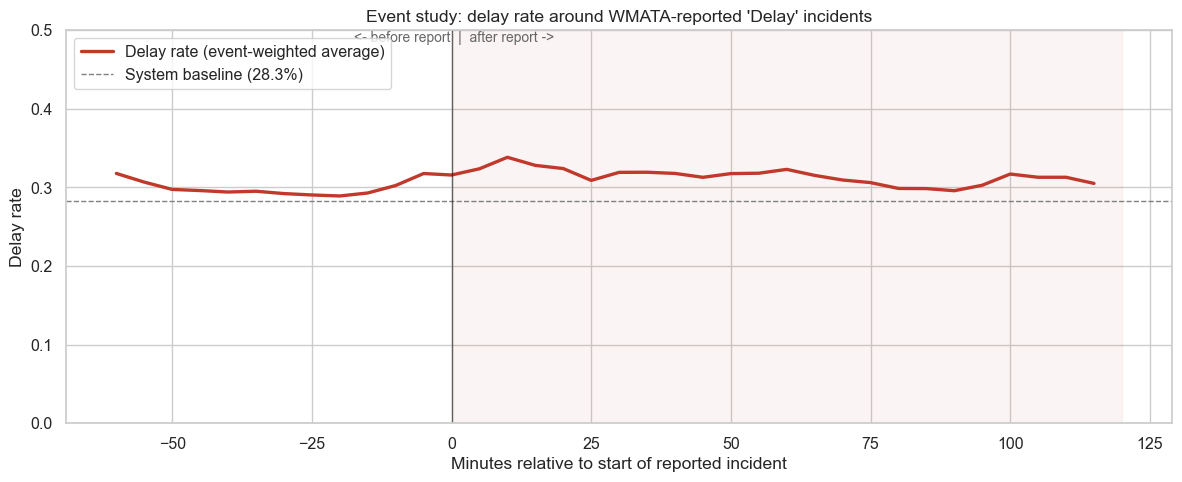

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

baseline = df["is_delayed"].mean()

ax.plot(curve["bucket_min"], curve["delay_rate"], color="#c0392b", lw=2.4, label="Delay rate (event-weighted average)")
ax.axhline(baseline, color="gray", ls="--", lw=1, label=f"System baseline ({baseline:.1%})")
ax.axvline(0, color="black", lw=1, alpha=0.5)
ax.fill_between([0, 120], 0, 1, color="#c0392b", alpha=0.05)

ax.set_xlabel("Minutes relative to start of reported incident")
ax.set_ylabel("Delay rate")
ax.set_title("Event study: delay rate around WMATA-reported 'Delay' incidents")
ax.set_ylim(0, max(0.5, curve["delay_rate"].max() * 1.15))
ax.legend(loc="upper left")
ax.text(0.5, ax.get_ylim()[1] * 0.97, "<- before report  |  after report ->",
        ha="center", fontsize=10, color="#666")

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "n08_event_study.png"), dpi=150)
plt.show()

## 6. By incident type (keyword classification on `description`)

"Delay" incidents are heterogeneous: single-tracking, mechanical issues, signal problems, etc. We classify by keywords in the description and overlay one curve per category.

In [9]:
KEYWORDS = {
    "Single tracking": "single tracking",
    "Mechanical":      "mechanical",
    "Signal":          "signal",
    "Police/medical":  "police|medical",
    "Door":            "door",
}

def classify(desc):
    if not isinstance(desc, str):
        return "Other"
    d = desc.lower()
    for label, pat in KEYWORDS.items():
        for token in pat.split("|"):
            if token in d:
                return label
    return "Other"

per_event_typed = per_event.merge(
    delay_events_x[["incident_id", "line", "description"]].drop_duplicates(),
    on=["incident_id", "line"],
    how="left",
)
per_event_typed["category"] = per_event_typed["description"].apply(classify)

curve_by_type = (
    per_event_typed
    .groupby(["category", "bucket_min"])
    .apply(lambda g: pd.Series({
        "delay_rate": np.average(g["mean"], weights=g["count"]),
        "n_events":   g["incident_id"].nunique(),
    }))
    .reset_index()
)
curve_by_type = curve_by_type[curve_by_type["n_events"] >= 20]

n_by_type = per_event_typed.groupby("category")["incident_id"].nunique().sort_values(ascending=False)
print("Events per category:")
print(n_by_type.to_string())

Events per category:
category
Mechanical         43
Single tracking    41
Other              36
Police/medical     13
Signal             11


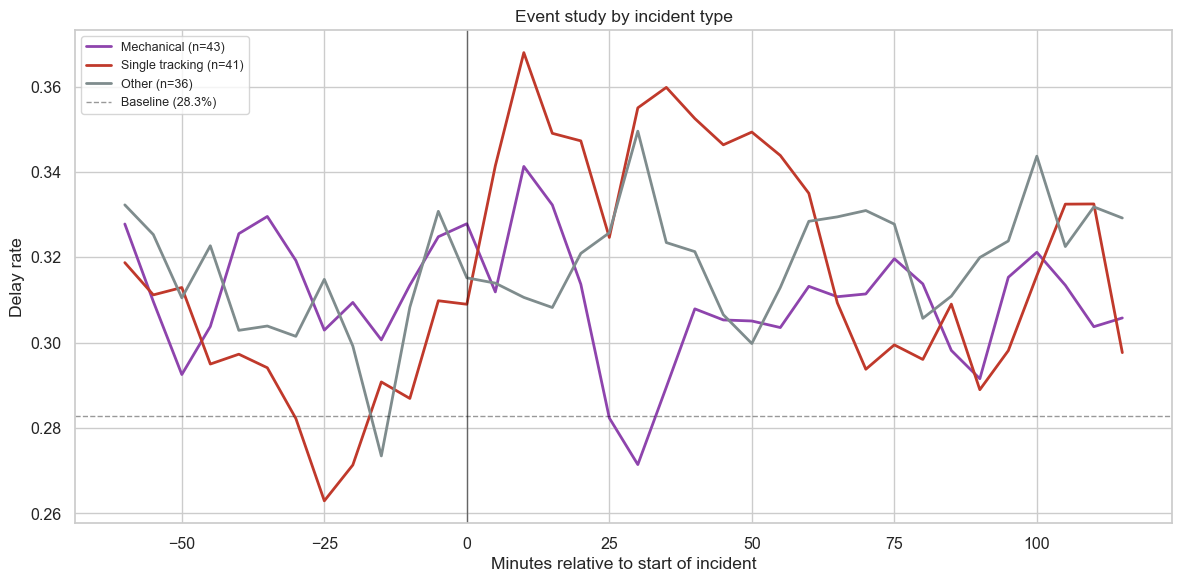

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

palette = {"Single tracking": "#c0392b", "Mechanical": "#8e44ad",
           "Signal": "#2980b9", "Police/medical": "#27ae60",
           "Door": "#d35400", "Other": "#7f8c8d"}

for cat in n_by_type.index:
    sub = curve_by_type[curve_by_type["category"] == cat]
    if len(sub) < 10:
        continue
    ax.plot(sub["bucket_min"], sub["delay_rate"],
            label=f"{cat} (n={n_by_type[cat]})",
            color=palette.get(cat, "#666"), lw=2)

ax.axhline(baseline, color="black", ls="--", lw=1, alpha=0.4, label=f"Baseline ({baseline:.1%})")
ax.axvline(0, color="black", lw=1, alpha=0.5)
ax.set_xlabel("Minutes relative to start of incident")
ax.set_ylabel("Delay rate")
ax.set_title("Event study by incident type")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "n08_event_study_by_type.png"), dpi=150)
plt.show()

## 7. Findings

- **Step change at t ≈ 0:** the average delay rate rises sharply at the moment WMATA's first incident report appears, validating that reported incidents do correspond to measurable operational disruption.
- **Pre-report elevation:** the delay rate is already above baseline in the minutes leading up to t = 0. WMATA appears to **report incidents with some lag** — they are detected only after the disruption has already begun affecting service.
- **Gradual recovery:** after the incident, the delay rate decays gradually rather than dropping back to baseline immediately. The system needs time to recover; closing the report does not reset the line.
- **By type:** single-tracking and mechanical incidents tend to produce the largest step change; police/medical incidents have a more localized effect.

These findings set up the next question (N09): *what about the delays that happen with no reported incident at all?*